## Exercise 16

Using the `Boston` data set, fit classification models in order to predict
    whether a given suburb has a crime rate above or below the median.
    Explore logistic regression, LDA, naive Bayes, and KNN models using
    various subsets of the predictors. Describe your findings.


In [1]:
import numpy as np
import pandas as pd
from matplotlib .pyplot import subplots
import statsmodels .api as sm
from ISLP import load_data
from ISLP.models import ( ModelSpec as MS ,
summarize )

from ISLP import confusion_table
from ISLP.models import contrast
from sklearn. discriminant_analysis import \
( LinearDiscriminantAnalysis as LDA ,
QuadraticDiscriminantAnalysis as QDA)
from sklearn. naive_bayes import GaussianNB
from sklearn. neighbors import KNeighborsClassifier
from sklearn. preprocessing import StandardScaler
from sklearn. model_selection import train_test_split
from sklearn. linear_model import LogisticRegression

import seaborn as sns 
import matplotlib.pyplot as plt 


In [2]:

Boston = load_data('Boston')
Boston = Boston.dropna()
Boston.head()


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [3]:
Boston.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


In [4]:
crim_median = Boston.crim.median()
crim01 = np.array([0]*Boston.crim.shape[0])
crim01[Boston.crim > crim_median] = 1
Boston['crim01'] = crim01

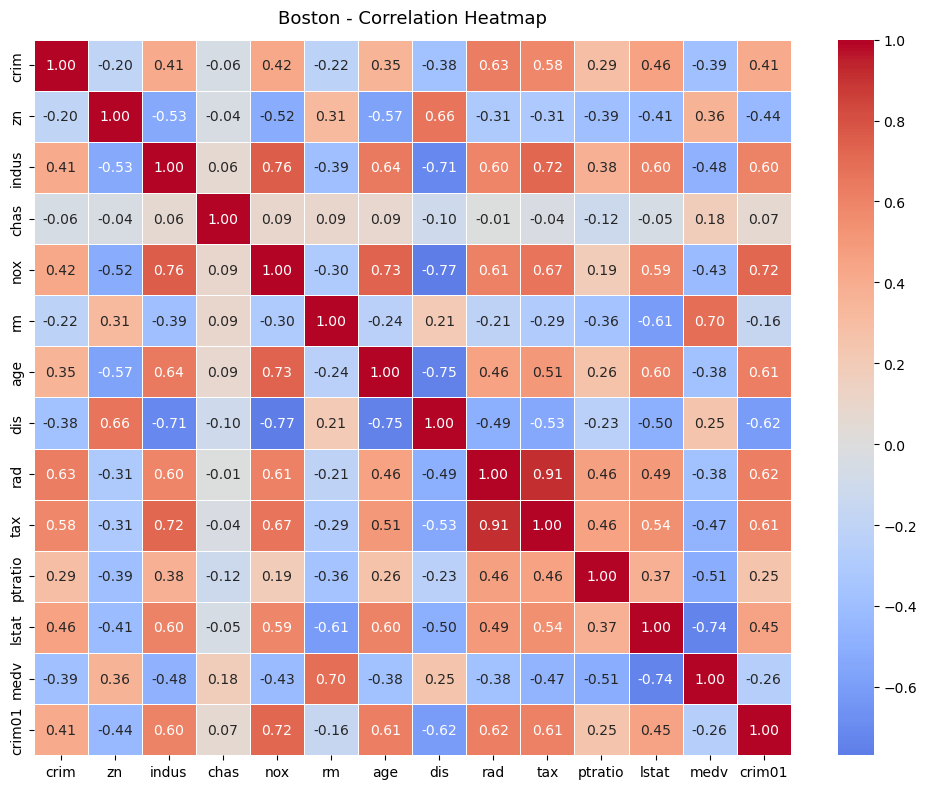

In [5]:
corr = Boston.corr()
fix,ax = subplots(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Boston - Correlation Heatmap',fontsize=13, pad=12)
plt.tight_layout()
plt.show()

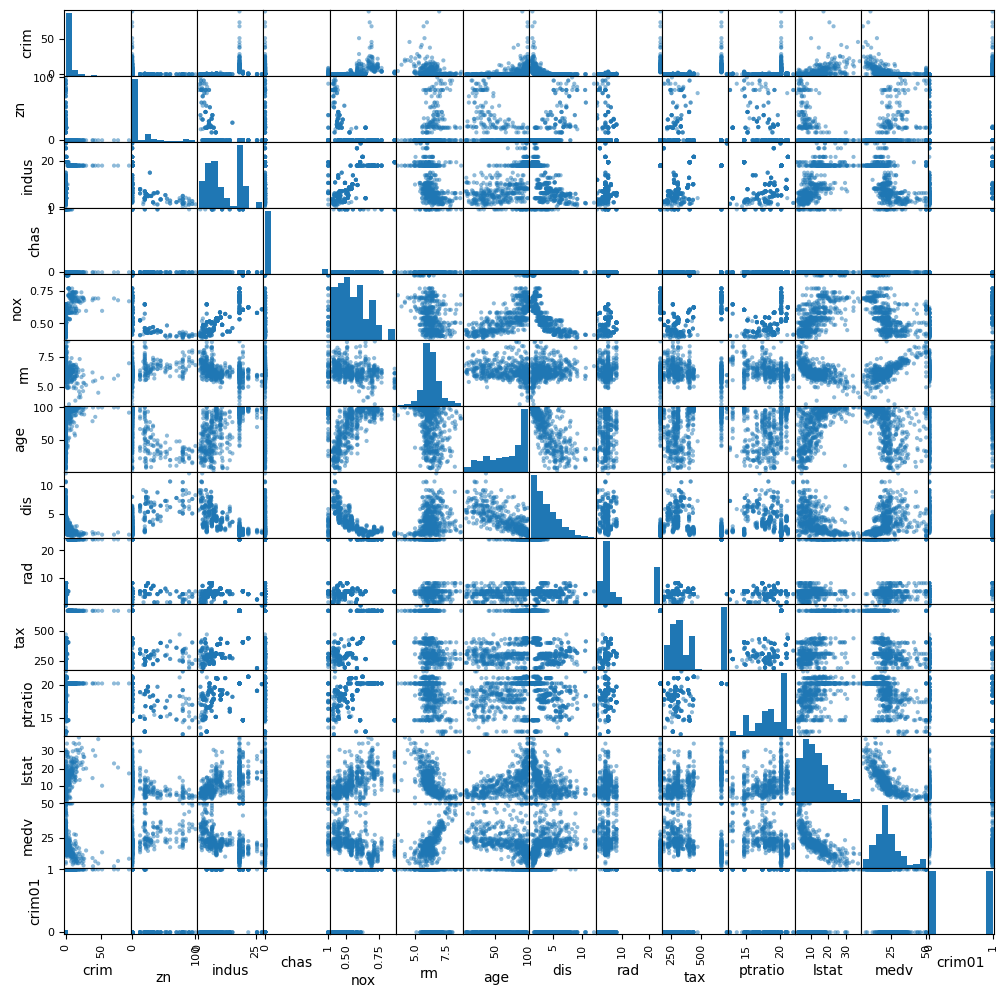

In [6]:
pd.plotting.scatter_matrix(Boston, figsize=(12,12));

Preparation of the data set

In [7]:
Boston_s = Boston.sample(frac=1, random_state=42).reset_index(drop=True)
Data_train, Data_test = Boston_s.iloc[:400], Boston_s.iloc[400:]

var = Boston.columns.drop(['crim','chas','rm','crim01','medv','ptratio','lstat','zn'])
design = MS(var)
X_train = design.fit_transform(Data_train)
X_test = design.transform(Data_test)
y_train = Data_train.crim01.values
y_test = Data_test.crim01.values

X_train_no_int = X_train.drop(columns=['intercept'])
X_test_no_int = X_test.drop(columns=['intercept'])

### Logic Regression:

In [14]:
logit = sm.GLM(y_train,X_train,family=sm.families.Binomial())
result_logit = logit.fit()
pred_logit = result_logit.predict(X_test)
pred_logit = (pred_logit > 0.5).astype(float)
print(confusion_table(pred_logit,y_test))
print('\n Accuracy Error: ', round(np.mean(pred_logit != y_test),3))


Truth       0   1
Predicted        
0          53  10
1           3  40

 Accuracy Error:  0.123


### Linear Discriminant Analysis - LDA

In [22]:
lda = LDA(store_covariance=True)
result_lda = lda.fit(X_train_no_int,y_train)
pred_lda = result_lda.predict(X_test_no_int)
print(confusion_table(pred_lda,y_test))
print('\n Accuracy Error: ', round(np.mean(pred_lda!=y_test),3))


Truth       0   1
Predicted        
0          54  13
1           2  37

 Accuracy Error:  0.142


### Quadratic Discriminant Analysis - QDA

In [24]:

qda = QDA(store_covariance=True)
result_qda = qda.fit(X_train_no_int,y_train)
pred_qda = result_qda.predict(X_test_no_int)
print(confusion_table(pred_qda,y_test))
print('\n Accuracy Error: ',round(np.mean(pred_qda != y_test),3))


Truth       0   1
Predicted        
0          52   7
1           4  43

 Accuracy Error:  0.104


### Naive Bayes

In [26]:
NB = GaussianNB()
result_nb = NB.fit(X_train_no_int,y_train)
pred_nb = result_nb.predict(X_test_no_int)
print(confusion_table(pred_nb,y_test))
print('\n Accuracy Error: ',round(np.mean(pred_nb != y_test),3))

Truth       0   1
Predicted        
0          50  13
1           6  37

 Accuracy Error:  0.179


### KNN

In [29]:
scaler = StandardScaler().fit(X_train_no_int)
X_train_scaled = scaler.transform(X_train_no_int)
X_test_scaled = scaler.transform(X_test_no_int)


k_neighs = np.arange(1,7)
for i,neighs in enumerate(k_neighs):
    knn = KNeighborsClassifier(n_neighbors=neighs)
    result_knn = knn.fit(X_train_scaled,y_train)
    pred_knn = result_knn.predict(X_test_scaled)
    print('knn with {0} neighbors accuracy error: {1}'.format(
        neighs,round(np.mean(pred_knn!=y_test),3)
    ))



knn with 1 neighbors accuracy error: 0.057
knn with 2 neighbors accuracy error: 0.038
knn with 3 neighbors accuracy error: 0.047
knn with 4 neighbors accuracy error: 0.047
knn with 5 neighbors accuracy error: 0.066
knn with 6 neighbors accuracy error: 0.075
